# The Data Machine — Validación de VADER y extracción de temas

**Proyecto:** La Máquina de Datos  
**Responsable del bloque:** Yariel Navarrete Flores  
**Materia:** Desarrollo de Aplicaciones para Análisis de Datos  
**Institución:** ESCOM — Instituto Politécnico Nacional

Este notebook utiliza exclusivamente los resultados generados por `src/nlp.py`. Su propósito es:

1. Verificar la integridad de las 5,000 reseñas analizadas.
2. Comparar VADER con la recomendación original de Steam (`voted_up`).
3. Contrastar la exactitud de VADER con un baseline de clase mayoritaria.
4. Analizar cobertura, exactitud balanceada y matriz de confusión.
5. Mostrar temas TF-IDF, bigramas, etiquetas de Steam y nube de palabras.

> El dataset principal `dataset_limpio.csv` se conserva sin modificaciones.

In [1]:
# ============================================================
# 1. IMPORTACIONES Y CONFIGURACIÓN DE RUTAS
# ============================================================

from pathlib import Path
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from wordcloud import WordCloud


# El notebook puede ejecutarse desde la raíz del proyecto
# o desde la carpeta notebooks/. Esta lógica funciona en ambos casos.
RAIZ = Path.cwd().resolve()
if RAIZ.name == "notebooks":
    RAIZ = RAIZ.parent

RUTA_NLP = RAIZ / "data" / "processed" / "nlp"
RUTA_REVIEWS = RUTA_NLP / "reviews_analizadas.csv"
RUTA_METRICAS = RUTA_NLP / "metricas_sentimiento.json"
RUTA_TEMAS = RUTA_NLP / "temas_tfidf.csv"
RUTA_TAGS = RUTA_NLP / "tags_steam.csv"

# Parámetros esperados según el alcance del proyecto.
JUEGOS_ESPERADOS = 10
REVIEWS_ESPERADAS_POR_JUEGO = 500
TEMAS_ESPERADOS_POR_JUEGO = 15

# Videojuego utilizado en las visualizaciones detalladas.
# Puede cambiarse por cualquier appid del catálogo.
APPID_ANALISIS = 570

print(f"Raíz del proyecto: {RAIZ}")
print(f"Carpeta de resultados NLP: {RUTA_NLP}")

Raíz del proyecto: C:\Users\yari_\Desktop\the-data-machine
Carpeta de resultados NLP: C:\Users\yari_\Desktop\the-data-machine\data\processed\nlp


In [2]:
# ============================================================
# 2. CARGA DE LOS RESULTADOS GENERADOS POR src/nlp.py
# ============================================================

archivos_requeridos = [
    RUTA_REVIEWS,
    RUTA_METRICAS,
    RUTA_TEMAS,
    RUTA_TAGS,
]

faltantes = [ruta for ruta in archivos_requeridos if not ruta.exists()]

if faltantes:
    nombres = "\n".join(f"- {ruta}" for ruta in faltantes)
    raise FileNotFoundError(
        "Faltan resultados del pipeline NLP:\n"
        f"{nombres}\n\n"
        "Ejecuta primero: python -m src.nlp --top-temas 15"
    )

reviews = pd.read_csv(RUTA_REVIEWS)
temas = pd.read_csv(RUTA_TEMAS)
tags = pd.read_csv(RUTA_TAGS)

with RUTA_METRICAS.open("r", encoding="utf-8") as archivo:
    metricas_json = json.load(archivo)

metricas = pd.DataFrame(metricas_json)

print(f"Reseñas cargadas: {len(reviews):,}")
print(f"Juegos con métricas: {metricas['appid'].nunique()}")
print(f"Temas TF-IDF: {len(temas):,}")
print(f"Tags de Steam: {len(tags):,}")

Reseñas cargadas: 5,000
Juegos con métricas: 10
Temas TF-IDF: 150
Tags de Steam: 150


In [3]:
# ============================================================
# 3. VALIDACIÓN ESTRUCTURAL DEL CORPUS
# ============================================================

appids_reviews = set(reviews["appid"].astype(int))
appids_metricas = set(metricas["appid"].astype(int))
appids_temas = set(temas["appid"].astype(int))
appids_tags = set(tags["appid"].astype(int))

duplicados = int(reviews["review_hash"].duplicated().sum())
textos_vacios = int(reviews["text"].fillna("").str.strip().eq("").sum())
conteo_por_juego = reviews.groupby(["appid", "game_name"]).size().rename("reviews")
temas_por_juego = temas.groupby(["appid", "game_name"]).size().rename("temas")
tags_por_juego = tags.groupby(["appid", "game_name"]).size().rename("tags")

validaciones = pd.DataFrame(
    {
        "validacion": [
            "Cantidad de juegos",
            "Total de reseñas",
            "Hashes duplicados",
            "Textos vacíos",
            "Mismos appids en todas las salidas",
            "500 reseñas por juego",
            "15 temas por juego",
            "15 tags por juego",
        ],
        "resultado": [
            len(appids_reviews) == JUEGOS_ESPERADOS,
            len(reviews) == JUEGOS_ESPERADOS * REVIEWS_ESPERADAS_POR_JUEGO,
            duplicados == 0,
            textos_vacios == 0,
            appids_reviews == appids_metricas == appids_temas == appids_tags,
            bool((conteo_por_juego == REVIEWS_ESPERADAS_POR_JUEGO).all()),
            bool((temas_por_juego == TEMAS_ESPERADOS_POR_JUEGO).all()),
            bool((tags_por_juego == TEMAS_ESPERADOS_POR_JUEGO).all()),
        ],
    }
)

display(validaciones)
display(conteo_por_juego.reset_index())

if not validaciones["resultado"].all():
    raise AssertionError(
        "Una o más validaciones fallaron. Revisa las tablas anteriores."
    )

print("RESULTADO: TODAS LAS VALIDACIONES ESTRUCTURALES FUERON APROBADAS.")

,validacion,resultado
0,Cantidad de juegos,True
1,Total de reseñas,True
2,Hashes duplicados,True
3,Textos vacíos,True
4,Mismos appids en todas las salidas,True
5,500 reseñas por juego,True
6,15 temas por juego,True
7,15 tags por juego,True


,appid,game_name,reviews
0,570,Dota 2,500
1,236390,War Thunder,500
2,252490,Rust,500
3,292030,The Witcher 3: Wild Hunt,500
4,367520,Hollow Knight,500
5,413150,Stardew Valley,500
6,739630,Phasmophobia,500
7,945360,Among Us,500
8,1172470,Apex Legends™,500
9,1245620,ELDEN RING,500


RESULTADO: TODAS LAS VALIDACIONES ESTRUCTURALES FUERON APROBADAS.


## Evaluación del análisis de sentimiento

La recomendación original de Steam se usa como referencia binaria:

- `voted_up = True`: reseña positiva.
- `voted_up = False`: reseña negativa.

VADER puede producir una tercera clase, **neutral**. Las reseñas neutrales se excluyen de las métricas binarias y se reportan mediante `coverage_non_neutral`.

La exactitud debe analizarse junto con el **baseline de clase mayoritaria**, porque varios juegos presentan un fuerte desequilibrio entre reseñas positivas y negativas.

In [4]:
# ============================================================
# 4. TABLA COMPARATIVA DE MÉTRICAS
# ============================================================

columnas_resumen = [
    "appid",
    "game_name",
    "reviews_total",
    "coverage_non_neutral",
    "accuracy_non_neutral",
    "balanced_accuracy_non_neutral",
    "f1_positive_non_neutral",
    "majority_baseline_non_neutral",
    "steam_positive_pct_sample",
    "vader_positive_pct_all",
    "steam_positive_pct_dataset",
    "absolute_error_vader_vs_dataset_pct",
]

columnas_disponibles = [
    columna for columna in columnas_resumen if columna in metricas.columns
]

resumen = metricas[columnas_disponibles].copy()

resumen["cumple_accuracy_75"] = (
    resumen["accuracy_non_neutral"].fillna(0) >= 0.75
)

resumen["supera_baseline"] = (
    resumen["accuracy_non_neutral"].fillna(0)
    > resumen["majority_baseline_non_neutral"].fillna(0)
)

resumen["balanced_accuracy_70"] = (
    resumen["balanced_accuracy_non_neutral"].fillna(0) >= 0.70
)

resumen = resumen.sort_values(
    "balanced_accuracy_non_neutral",
    ascending=False,
).reset_index(drop=True)

display(resumen)

print(
    "Juegos con accuracy >= 75%:",
    int(resumen["cumple_accuracy_75"].sum()),
    "de",
    len(resumen),
)
print(
    "Juegos donde VADER supera el baseline:",
    int(resumen["supera_baseline"].sum()),
    "de",
    len(resumen),
)
print(
    "Juegos con balanced accuracy >= 70%:",
    int(resumen["balanced_accuracy_70"].sum()),
    "de",
    len(resumen),
)

,appid,game_name,reviews_total,coverage_non_neutral,accuracy_non_neutral,balanced_accuracy_non_neutral,f1_positive_non_neutral,majority_baseline_non_neutral,steam_positive_pct_sample,vader_positive_pct_all,steam_positive_pct_dataset,absolute_error_vader_vs_dataset_pct,cumple_accuracy_75,supera_baseline,balanced_accuracy_70
0,945360,Among Us,500,0.706,0.866856,0.821924,0.924071,0.926346,92.2,58.4,92.0,33.6,True,False,True
1,292030,The Witcher 3: Wild Hunt,500,0.728,0.934066,0.803756,0.965318,0.975275,97.4,67.4,96.0,28.6,True,False,True
2,1172470,Apex Legends™,500,0.744,0.817204,0.793233,0.866142,0.690860,70.4,50.2,67.0,16.8,True,True,True
3,413150,Stardew Valley,500,0.820,0.936585,0.757178,0.966921,0.982927,98.6,76.6,98.0,21.4,True,False,True
4,570,Dota 2,500,0.568,0.781690,0.730270,0.848039,0.718310,71.4,40.8,81.0,40.2,True,True,True
5,252490,Rust,500,0.766,0.707572,0.718224,0.781250,0.749347,74.2,45.0,87.0,42.0,False,False,True
6,236390,War Thunder,500,0.770,0.693506,0.704352,0.687831,0.568831,44.4,42.4,73.0,30.6,False,True,True
7,367520,Hollow Knight,500,0.748,0.831551,0.669399,0.906942,0.978610,98.0,62.2,97.0,34.8,True,False,False
8,739630,Phasmophobia,500,0.814,0.707617,0.668706,0.782450,0.673219,71.2,54.6,96.0,41.4,False,True,False
9,1245620,ELDEN RING,500,0.742,0.768194,0.590858,0.864780,0.929919,93.0,58.2,92.0,33.8,True,False,False


Juegos con accuracy >= 75%: 7 de 10
Juegos donde VADER supera el baseline: 4 de 10
Juegos con balanced accuracy >= 70%: 7 de 10


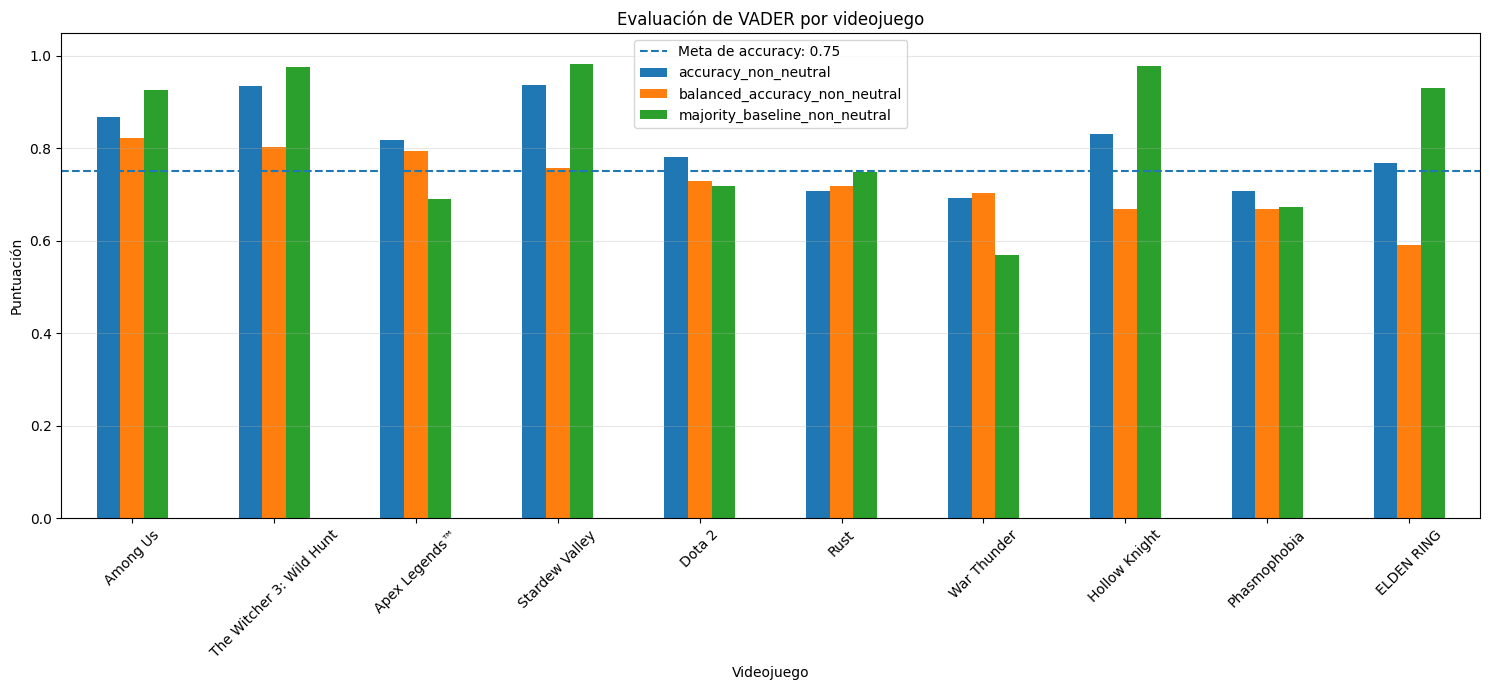

In [5]:
# ============================================================
# 5. EXACTITUD, EXACTITUD BALANCEADA Y BASELINE
# ============================================================

grafica_metricas = resumen.set_index("game_name")[[
    "accuracy_non_neutral",
    "balanced_accuracy_non_neutral",
    "majority_baseline_non_neutral",
]]

ax = grafica_metricas.plot(
    kind="bar",
    figsize=(15, 7),
)

ax.axhline(
    0.75,
    linestyle="--",
    linewidth=1.5,
    label="Meta de accuracy: 0.75",
)

ax.set_title("Evaluación de VADER por videojuego")
ax.set_xlabel("Videojuego")
ax.set_ylabel("Puntuación")
ax.set_ylim(0, 1.05)
ax.tick_params(axis="x", rotation=45)
ax.grid(axis="y", alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

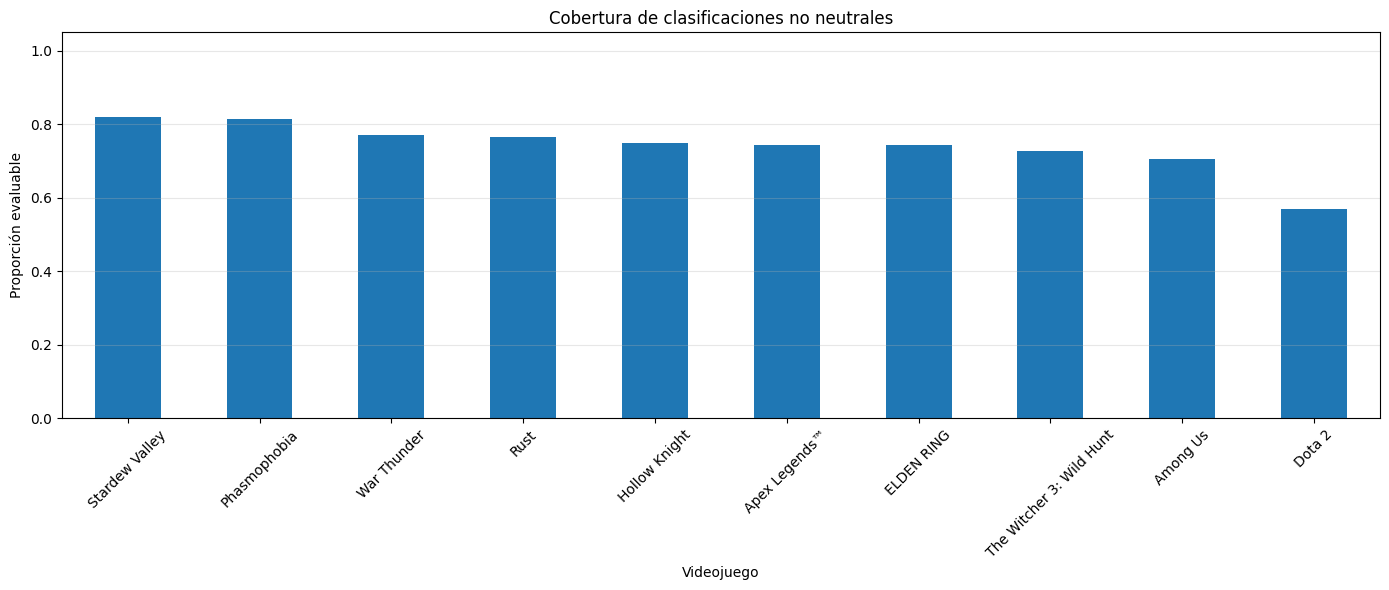

In [6]:
# ============================================================
# 6. COBERTURA DE VADER
# ============================================================

cobertura = resumen.sort_values(
    "coverage_non_neutral",
    ascending=False,
)

ax = cobertura.plot(
    x="game_name",
    y="coverage_non_neutral",
    kind="bar",
    figsize=(14, 6),
    legend=False,
)

ax.set_title("Cobertura de clasificaciones no neutrales")
ax.set_xlabel("Videojuego")
ax.set_ylabel("Proporción evaluable")
ax.set_ylim(0, 1.05)
ax.tick_params(axis="x", rotation=45)
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

## Análisis detallado por videojuego

En la celda de configuración puede modificarse `APPID_ANALISIS`. Las siguientes visualizaciones se actualizarán automáticamente para el juego seleccionado.

In [7]:
# ============================================================
# 7. SELECCIÓN Y RESUMEN DEL JUEGO
# ============================================================

if APPID_ANALISIS not in appids_reviews:
    raise ValueError(
        f"El appid {APPID_ANALISIS} no existe en los resultados. "
        f"Appids disponibles: {sorted(appids_reviews)}"
    )

reviews_juego = reviews[reviews["appid"] == APPID_ANALISIS].copy()
metricas_juego = metricas[metricas["appid"] == APPID_ANALISIS].iloc[0]
temas_juego = temas[temas["appid"] == APPID_ANALISIS].copy()
tags_juego = tags[tags["appid"] == APPID_ANALISIS].copy()

nombre_juego = str(metricas_juego["game_name"])

resumen_juego = pd.DataFrame(
    {
        "metrica": [
            "Reseñas totales",
            "Cobertura no neutral",
            "Accuracy no neutral",
            "Balanced accuracy",
            "F1 positivo",
            "Baseline mayoritario",
            "% positivo en muestra Steam",
            "% positivo según VADER",
            "% positivo histórico del dataset",
        ],
        "valor": [
            int(metricas_juego["reviews_total"]),
            metricas_juego["coverage_non_neutral"],
            metricas_juego["accuracy_non_neutral"],
            metricas_juego["balanced_accuracy_non_neutral"],
            metricas_juego["f1_positive_non_neutral"],
            metricas_juego["majority_baseline_non_neutral"],
            metricas_juego["steam_positive_pct_sample"],
            metricas_juego["vader_positive_pct_all"],
            metricas_juego.get("steam_positive_pct_dataset"),
        ],
    }
)

print(f"Videojuego seleccionado: {nombre_juego} ({APPID_ANALISIS})")
display(resumen_juego)

Videojuego seleccionado: Dota 2 (570)


,metrica,valor
0,Reseñas totales,500.000000
1,Cobertura no neutral,0.568000
2,Accuracy no neutral,0.781690
3,Balanced accuracy,0.730270
4,F1 positivo,0.848039
5,Baseline mayoritario,0.718310
6,% positivo en muestra Steam,71.400000
7,% positivo según VADER,40.800000
8,% positivo histórico del dataset,81.000000


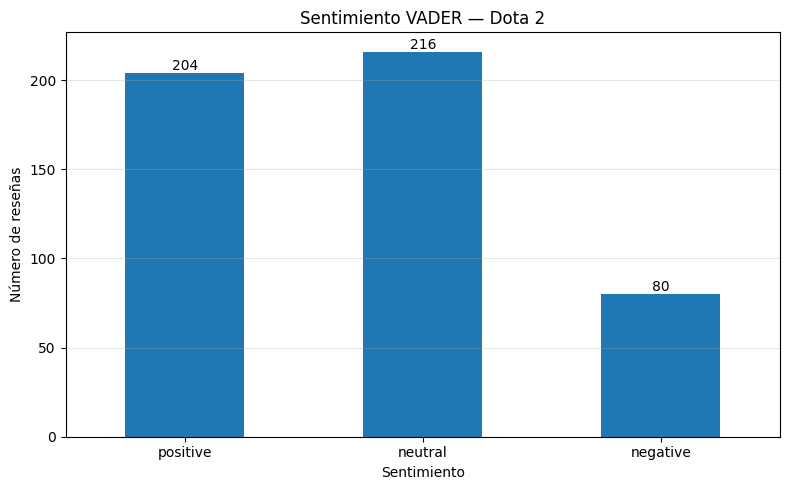

In [8]:
# ============================================================
# 8. DISTRIBUCIÓN DE SENTIMIENTO PARA EL JUEGO
# ============================================================

orden_sentimientos = ["positive", "neutral", "negative"]
conteos_sentimiento = (
    reviews_juego["sentiment_vader"]
    .value_counts()
    .reindex(orden_sentimientos, fill_value=0)
)

ax = conteos_sentimiento.plot(
    kind="bar",
    figsize=(8, 5),
)

ax.set_title(f"Sentimiento VADER — {nombre_juego}")
ax.set_xlabel("Sentimiento")
ax.set_ylabel("Número de reseñas")
ax.tick_params(axis="x", rotation=0)
ax.grid(axis="y", alpha=0.3)

for contenedor in ax.containers:
    ax.bar_label(contenedor)

plt.tight_layout()
plt.show()

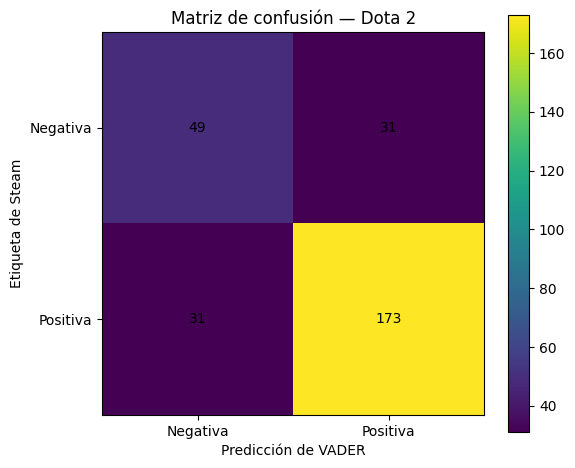

In [9]:
# ============================================================
# 9. MATRIZ DE CONFUSIÓN
# ============================================================

matriz_info = metricas_juego["confusion_matrix"]

matriz = np.array(
    [
        [
            matriz_info["true_negative"],
            matriz_info["false_positive"],
        ],
        [
            matriz_info["false_negative"],
            matriz_info["true_positive"],
        ],
    ]
)

fig, ax = plt.subplots(figsize=(6, 5))
imagen = ax.imshow(matriz)

ax.set_title(f"Matriz de confusión — {nombre_juego}")
ax.set_xlabel("Predicción de VADER")
ax.set_ylabel("Etiqueta de Steam")
ax.set_xticks([0, 1], labels=["Negativa", "Positiva"])
ax.set_yticks([0, 1], labels=["Negativa", "Positiva"])

for fila in range(2):
    for columna in range(2):
        ax.text(
            columna,
            fila,
            int(matriz[fila, columna]),
            ha="center",
            va="center",
        )

fig.colorbar(imagen, ax=ax)
plt.tight_layout()
plt.show()

## Extracción de temas

Los temas se obtienen con TF-IDF sobre reseñas individuales. Se usan unigramas y bigramas. Las etiquetas de Steam se presentan por separado porque representan categorías asignadas por la comunidad y no términos calculados por el modelo.

In [10]:
# ============================================================
# 10. TEMAS TF-IDF Y TAGS DE STEAM
# ============================================================

print(f"Top temas TF-IDF — {nombre_juego}")
display(
    temas_juego[[
        "term",
        "ngram_type",
        "tfidf_score",
        "document_frequency",
        "document_pct",
    ]].reset_index(drop=True)
)

print(f"Tags de Steam — {nombre_juego}")
display(
    tags_juego[[
        "tag",
        "tag_votes",
        "score_normalized",
    ]].reset_index(drop=True)
)

Top temas TF-IDF — Dota 2


,term,ngram_type,tfidf_score,document_frequency,document_pct
0,best,unigram,0.040686,27,5.4108
1,dota,unigram,0.036226,48,9.6192
2,nice,unigram,0.034960,18,3.6072
3,fun,unigram,0.017773,22,4.4088
4,life,unigram,0.015800,17,3.4068
5,love,unigram,0.015598,14,2.8056
6,it's,unigram,0.015007,27,5.4108
7,toxic,unigram,0.013826,16,3.2064
8,match,unigram,0.013052,19,3.8076
9,awesome,unigram,0.011993,8,1.6032


Tags de Steam — Dota 2


,tag,tag_votes,score_normalized
0,Free to Play,59933,1.000000
1,MOBA,20158,0.336342
2,Multiplayer,15359,0.256270
3,Strategy,14252,0.237799
4,e-sports,11780,0.196553
5,Team-Based,10962,0.182904
6,Competitive,8286,0.138254
7,Action,7920,0.132148
8,Online Co-Op,7464,0.124539
9,PvP,6046,0.100879


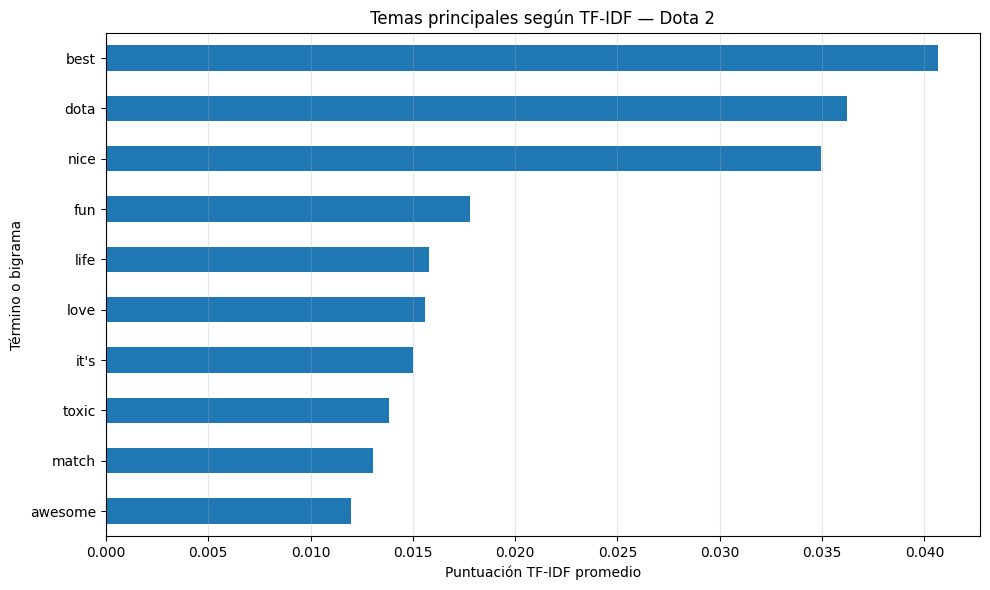

In [11]:
# ============================================================
# 11. GRÁFICA DE LOS DIEZ TEMAS PRINCIPALES
# ============================================================

temas_grafica = (
    temas_juego
    .sort_values("tfidf_score", ascending=True)
    .tail(10)
)

ax = temas_grafica.plot(
    x="term",
    y="tfidf_score",
    kind="barh",
    figsize=(10, 6),
    legend=False,
)

ax.set_title(f"Temas principales según TF-IDF — {nombre_juego}")
ax.set_xlabel("Puntuación TF-IDF promedio")
ax.set_ylabel("Término o bigrama")
ax.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

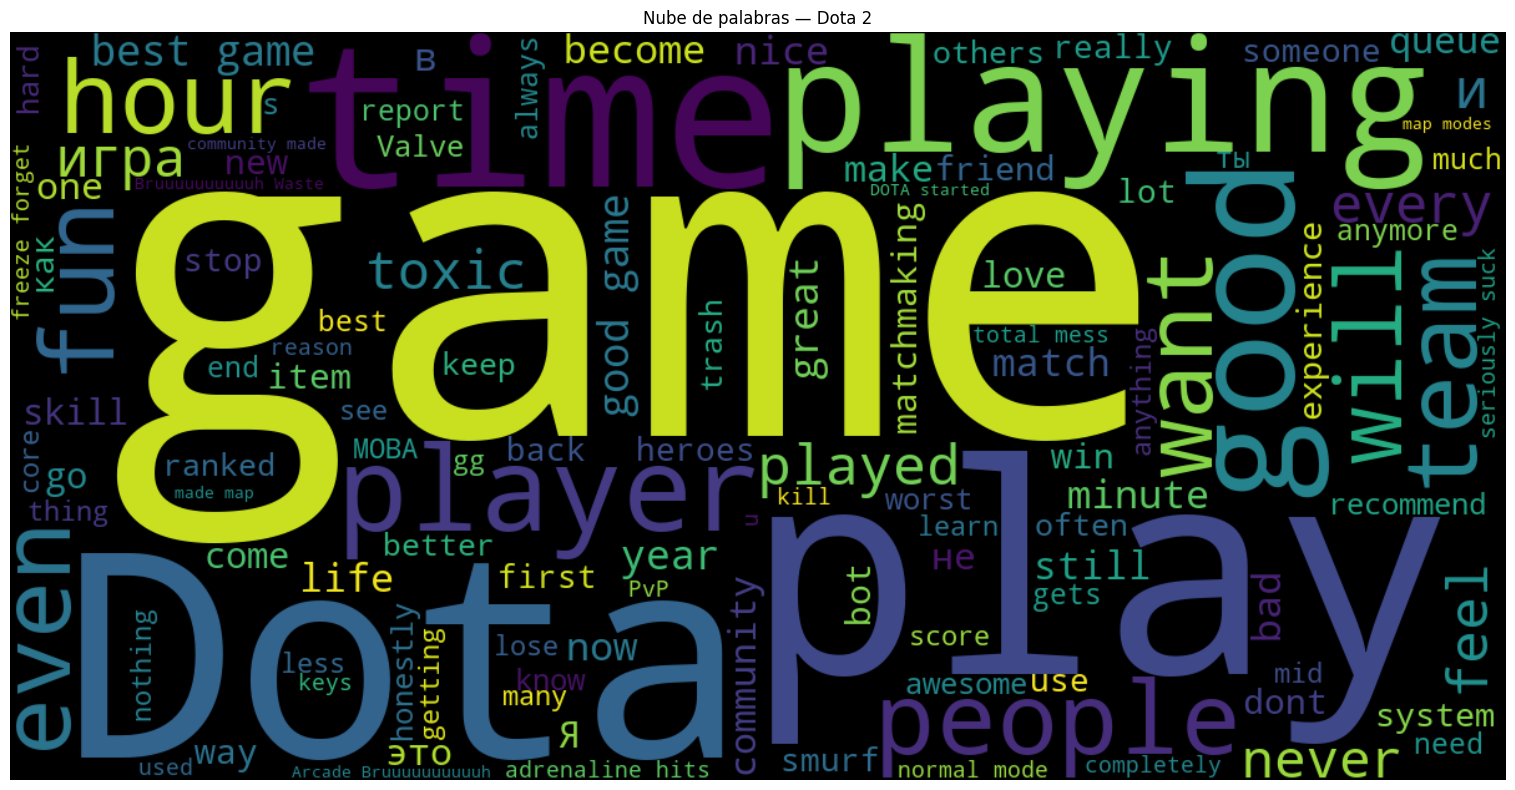

In [12]:
# ============================================================
# 12. NUBE DE PALABRAS
# ============================================================

corpus = " ".join(
    reviews_juego["text"]
    .fillna("")
    .astype(str)
    .tolist()
)

nube = WordCloud(
    width=1200,
    height=600,
    max_words=120,
    collocations=True,
).generate(corpus)

plt.figure(figsize=(16, 8))
plt.imshow(nube, interpolation="bilinear")
plt.axis("off")
plt.title(f"Nube de palabras — {nombre_juego}")
plt.tight_layout()
plt.show()

In [13]:
# ============================================================
# 13. CONCLUSIONES AUTOMÁTICAS Y EXPORTACIÓN DEL RESUMEN
# ============================================================

total_juegos = len(resumen)
cumple_accuracy = int(resumen["cumple_accuracy_75"].sum())
supera_baseline = int(resumen["supera_baseline"].sum())
balanced_70 = int(resumen["balanced_accuracy_70"].sum())

print("CONCLUSIONES DEL EXPERIMENTO")
print("-" * 60)
print(
    f"1. VADER alcanzó accuracy >= 75% en "
    f"{cumple_accuracy} de {total_juegos} videojuegos."
)
print(
    f"2. VADER superó el baseline de clase mayoritaria en "
    f"{supera_baseline} de {total_juegos} videojuegos."
)
print(
    f"3. La balanced accuracy fue >= 70% en "
    f"{balanced_70} de {total_juegos} videojuegos."
)
print(
    "4. Una accuracy alta no garantiza un modelo útil cuando la "
    "clase positiva domina; por eso se comparó contra el baseline."
)
print(
    "5. Los resultados deben presentarse como una evaluación real "
    "de las fortalezas y limitaciones de VADER, sin alterar umbrales."
)

ruta_resumen = RUTA_NLP / "resumen_evaluacion.csv"
resumen.to_csv(ruta_resumen, index=False, encoding="utf-8")

print(f"\nResumen exportado en: {ruta_resumen}")
print("RESULTADO: NOTEBOOK EJECUTADO CORRECTAMENTE.")

CONCLUSIONES DEL EXPERIMENTO
------------------------------------------------------------
1. VADER alcanzó accuracy >= 75% en 7 de 10 videojuegos.
2. VADER superó el baseline de clase mayoritaria en 4 de 10 videojuegos.
3. La balanced accuracy fue >= 70% en 7 de 10 videojuegos.
4. Una accuracy alta no garantiza un modelo útil cuando la clase positiva domina; por eso se comparó contra el baseline.
5. Los resultados deben presentarse como una evaluación real de las fortalezas y limitaciones de VADER, sin alterar umbrales.

Resumen exportado en: C:\Users\yari_\Desktop\the-data-machine\data\processed\nlp\resumen_evaluacion.csv
RESULTADO: NOTEBOOK EJECUTADO CORRECTAMENTE.


## Interpretación metodológica

Los resultados no deben evaluarse únicamente con la exactitud global. En juegos con una proporción muy alta de reseñas positivas, un clasificador que siempre predijera “positivo” podría obtener una exactitud aparentemente excelente. Por esta razón:

- Se reporta el baseline de clase mayoritaria.
- Se utiliza balanced accuracy para dar el mismo peso a las clases positiva y negativa.
- Se informa la cobertura de VADER, ya que las reseñas neutrales no participan en la evaluación binaria.
- Los temas TF-IDF y las etiquetas de Steam se mantienen separados para evitar confundir resultados calculados con metadata de la plataforma.

Este análisis permite concluir de manera reproducible en qué videojuegos VADER aporta valor y en cuáles queda limitado por sarcasmo, jerga, contexto o desequilibrio de clases.